In [1]:
import destruction_models as models
from tensorflow.keras import callbacks, metrics
from tensorflow.keras.utils import Sequence
from destruction_utilities import *
import matplotlib.pyplot as plt
import tensorflow as tf
import time
import pickle
from tensorflow.keras.models import load_model
from sklearn.metrics import precision_recall_curve, roc_auc_score, precision_score, recall_score


Metal device set to: Apple M1


2022-07-14 17:37:01.139537: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2022-07-14 17:37:01.139659: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [2]:
CITY = 'test'
BATCH_SIZE = 32
TILE_SIZE = [128,128]

In [3]:
class SiameseGenerator(Sequence):
    def __init__(self, images, labels, batch_size=BATCH_SIZE):
        self.images_t0 = images[0]
        self.images_tt = images[1]
        self.labels = labels
        self.batch_size = batch_size
        self.tuple_pairs = make_tuple_pair(self.images_t0.shape[0], self.batch_size)
        np.random.shuffle(self.tuple_pairs)
   
   
    def __len__(self):
        return len(self.images_t0)//self.batch_size
    
    def __getitem__(self, index):
        
        index_range = self.tuple_pairs[index]
        indices = np.arange(0,32)
        np.random.shuffle(indices)

        X_t0 = self.images_t0[index_range[0]:index_range[1]][indices]
        X_t1 = self.images_tt[index_range[0]:index_range[1]][indices]
        y = self.labels[index_range[0]:index_range[1]][indices]
        
        return {'images_t0':self.augment(X_t0), 'images_tt':self.augment(X_t1)}, y

    def augment(self, X):
#         # Horizontal and vertical flip
#         flipping_funcs = [
#             lambda image: image,
#             lambda image: np.fliplr(image),
#             lambda image: np.flipud(image),
#             lambda image: np.flipud(np.fliplr(image))
#         ]
#         func = random.choice(flipping_funcs)
#         X = func(X)
        
        # Brightness
        alpha = random.choice(np.linspace(0.85, 1.4))
        X = X * alpha

        return X

In [4]:
train_images_t0 = read_zarr(CITY, 'images_siamese_train_t0_balanced')
train_images_tt = read_zarr(CITY, 'images_siamese_train_tt_balanced')
train_labels = read_zarr(CITY, 'labels_siamese_train_balanced')

valid_images_t0 = read_zarr(CITY, 'images_siamese_valid_t0')
valid_images_tt = read_zarr(CITY, 'images_siamese_valid_tt')
valid_labels = read_zarr(CITY, 'labels_siamese_valid')


test_images_t0 = read_zarr(CITY, 'images_siamese_test_t0')
test_images_tt = read_zarr(CITY, 'images_siamese_test_tt')
test_labels = read_zarr(CITY, 'labels_siamese_valid')

train_gen = SiameseGenerator((train_images_t0, train_images_tt), train_labels)
valid_gen = SiameseGenerator((valid_images_t0, valid_images_tt), valid_labels)


In [5]:
def run_model(train_images, train_labels, valid_images, valid_labels, run_id = 1):
    train_gen = SiameseGenerator((train_images[0], train_images[1]), train_labels)
    valid_gen = SiameseGenerator((valid_images[0], valid_images[1]), valid_labels)
    
    training_callbacks = [
        callbacks.EarlyStopping(monitor='val_auc', patience=5, restore_best_weights=True),
        callbacks.ModelCheckpoint(f'../models/{CITY}/snn/run_{i}/', monitor='val_auc', verbose=0, save_best_only=True, save_weights_only=False, mode='max')
    ]
    
    filters = random.choice([16])
    dropout = random.choice(np.linspace(0.1, 0.2))
    epochs = random.choice(np.arange(70,100))
    units = random.choice([32, 48])
    lr = random.choice([0.003, 0.01, 0.03])

    args_encode  = dict(filters=filters, dropout=dropout) # ! Check parameters before run
    args_dense  = dict(units=units, dropout=dropout) # ! Check parameters before run

    parameters = f'filters={filters}, \ndropout={np.round(dropout, 4)}, \nepochs={epochs}, \nunits={units}, \nlearning_rate={lr}'
    print(parameters)
    
#     model = models.siamese_convolutional_network(shape=(*TILE_SIZE, 3), args_encode=args_encode, args_dense=args_dense)
    model = models.siamese_convolutional_network(shape=(*TILE_SIZE, 3),  args_encode=dict(filters=8, dropout=0), args_dense=dict(units=16, dropout=0))
   
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy',metrics.AUC(num_thresholds=200, curve='ROC', name='auc')])
    model.summary()
    

    # Train model on dataset
    history = model.fit_generator(
        train_gen,
        validation_data=valid_gen,
        epochs=epochs,
        verbose=1,
        callbacks=training_callbacks
    )
    
    return model, history, parameters

In [6]:
def plot_training(H, P, ts, plotPath):
	# construct a plot that plots and saves the training history
	plt.style.use("ggplot")
	plt.figure()
	plt.plot(H.history["accuracy"], label="train_accuracy")
	plt.plot(H.history["val_accuracy"], label="val_accuracy")
	plt.plot(H.history["auc"], label="train_auc")
	plt.plot(H.history["val_auc"], label="val_auc")
	plt.title(f"Training Accuracy and AUC")
	plt.suptitle(f"City = {CITY}") 
	plt.xlabel("Epoch #")
	plt.ylabel("AUC")
	plt.text(0.65, 0.18, P + f"\nmax(val_auc)={np.round(np.max(H.history['val_auc']), 4)}\ncode={ts}", fontsize=8, transform=plt.gcf().transFigure)
	plt.legend(loc="lower left")
	plt.savefig(plotPath)

filters=16, 
dropout=0.1, 
epochs=88, 
units=32, 
learning_rate=0.003
Model: "siamese_convolutional_network"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 images_t0 (InputLayer)         [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 images_tt (InputLayer)         [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 encoder (Functional)           (None, 640)          23736       ['images_t0[0][0]',              


/var/folders/z1/7pydgng971nfzdf2rwg_p__r0000gn/T/ipykernel_82031/1243927715.py:31: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model.fit_generator(
2022-07-14 17:37:01.564020: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz
2022-07-14 17:37:02.325869: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


17/17 [==============================] - ETA: 0s - loss: 0.8278 - accuracy: 0.6176 - auc: 0.6189

2022-07-14 17:37:03.989936: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2022-07-14 17:37:04.986434: W tensorflow/python/util/util.cc:368] Sets are not currently considered sequences, but this may change in the future, so consider avoiding using them.


INFO:tensorflow:Assets written to: ../models/test/snn/run_0/assets
17/17 [==============================] - 6s 267ms/step - loss: 0.8278 - accuracy: 0.6176 - auc: 0.6189 - val_loss: 29.0580 - val_accuracy: 0.1979 - val_auc: 0.5000
Epoch 2/88
17/17 [==============================] - 4s 263ms/step - loss: 0.5406 - accuracy: 0.7482 - auc: 0.7850 - val_loss: 6.0856 - val_accuracy: 0.1979 - val_auc: 0.5694
Epoch 3/88
17/17 [==============================] - 4s 232ms/step - loss: 0.4458 - accuracy: 0.8254 - auc: 0.8801 - val_loss: 1.6674 - val_accuracy: 0.3542 - val_auc: 0.6251
Epoch 4/88
17/17 [==============================] - 4s 245ms/step - loss: 0.3839 - accuracy: 0.8640 - auc: 0.9202 - val_loss: 1.1734 - val_accuracy: 0.4479 - val_auc: 0.6425
Epoch 5/88
17/17 [==============================] - 4s 236ms/step - loss: 0.3134 - accuracy: 0.9007 - auc: 0.9629 - val_loss: 0.7938 - val_accuracy: 0.6146 - val_auc: 0.7697
Epoch 6/88
17/17 [==============================] - 1s 58ms/step - loss: 

...

/var/folders/z1/7pydgng971nfzdf2rwg_p__r0000gn/T/ipykernel_82031/1243927715.py:31: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model.fit_generator(
2022-07-14 17:39:03.186126: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


17/17 [==============================] - ETA: 0s - loss: 0.7077 - accuracy: 0.5882 - auc: 0.5808

2022-07-14 17:39:04.924455: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


INFO:tensorflow:Assets written to: ../models/test/snn/run_4/assets
17/17 [==============================] - 6s 305ms/step - loss: 0.7077 - accuracy: 0.5882 - auc: 0.5808 - val_loss: 4.6750 - val_accuracy: 0.6250 - val_auc: 0.5379
Epoch 2/95
17/17 [==============================] - 2s 86ms/step - loss: 0.5432 - accuracy: 0.7298 - auc: 0.7233 - val_loss: 3.4569 - val_accuracy: 0.7396 - val_auc: 0.4481
Epoch 3/95
17/17 [==============================] - 1s 65ms/step - loss: 0.4554 - accuracy: 0.7739 - auc: 0.8368 - val_loss: 2.5805 - val_accuracy: 0.8021 - val_auc: 0.4545
Epoch 4/95
17/17 [==============================] - 4s 256ms/step - loss: 0.3631 - accuracy: 0.8566 - auc: 0.9098 - val_loss: 1.0417 - val_accuracy: 0.8021 - val_auc: 0.6278
Epoch 5/95
17/17 [==============================] - 5s 274ms/step - loss: 0.3319 - accuracy: 0.8474 - auc: 0.9211 - val_loss: 0.9960 - val_accuracy: 0.7500 - val_auc: 0.6411
Epoch 6/95
17/17 [==============================] - 1s 61ms/step - loss: 0.2

17/17 [==============================] - 1s 58ms/step - loss: 0.0018 - accuracy: 1.0000 - auc: 1.0000 - val_loss: 0.7397 - val_accuracy: 0.7604 - val_auc: 0.7830
Epoch 36/95
17/17 [==============================] - 1s 57ms/step - loss: 0.0017 - accuracy: 1.0000 - auc: 1.0000 - val_loss: 0.6654 - val_accuracy: 0.8333 - val_auc: 0.8066
Epoch 37/95
17/17 [==============================] - 1s 58ms/step - loss: 0.0016 - accuracy: 1.0000 - auc: 1.0000 - val_loss: 0.6009 - val_accuracy: 0.8229 - val_auc: 0.8489
Model optimization complete..




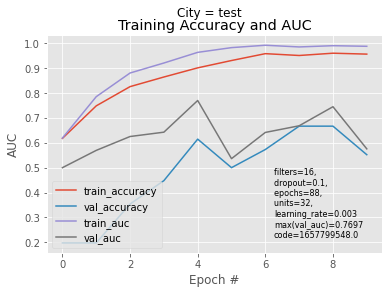

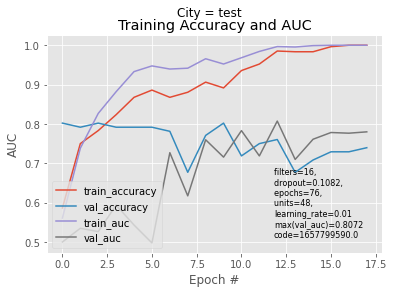

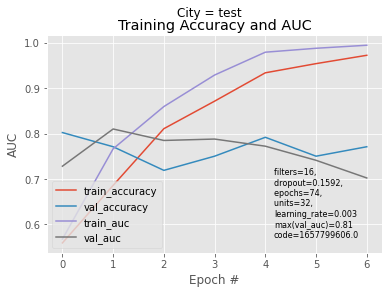

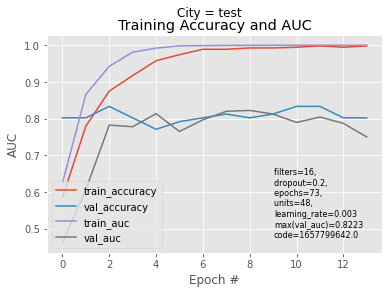

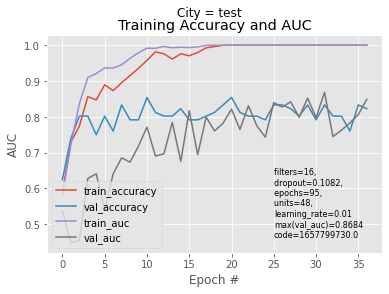

In [7]:
for i in range(0,5):
    m = run_model((train_images_t0, train_images_tt), train_labels, (valid_images_t0, valid_images_tt), valid_labels, run_id=i)
    model = m[0]
    history = m[1]
    parameters = m[2]
    print("Model optimization complete..\n\n")
    ts = str(np.round(time.time()))
    with open(f'../models/{CITY}_SNN_RUN{i}_{ts}_hist', 'wb') as file_pi:
        pickle.dump(history.history, file_pi)
    
    model.save(f'../models/{CITY}_SNN_RUN{i}_{ts}', save_format="h5")
    plot_training(history, parameters, ts, f'../figures/{CITY}_SNN_RUN{i}_{ts}.png')
    
    with open('../models/run_parameters.txt', "a") as file:
        file.write(f'{CITY}_SNN_RUN{i}_{ts}: \n \t{parameters}\n')
      


2022-07-14 17:41:28.659044: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


Run 1 
Test Set AUC Score for the ROC Curve: 0.5256916996047432


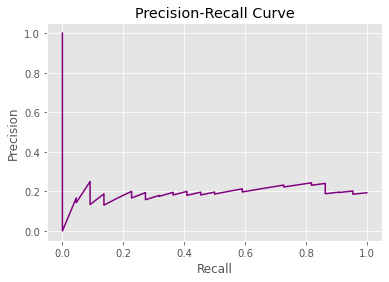

2022-07-14 17:41:31.505662: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


Run 2 
Test Set AUC Score for the ROC Curve: 0.6497035573122529


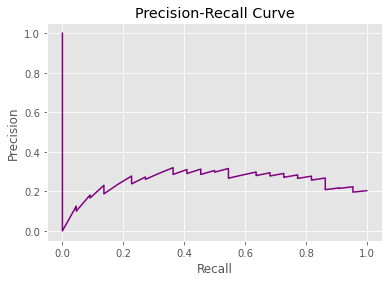

2022-07-14 17:41:34.781105: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


Run 3 
Test Set AUC Score for the ROC Curve: 0.7149209486166008


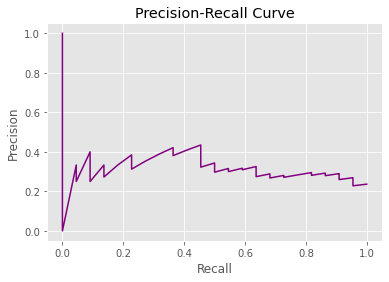

2022-07-14 17:41:38.115889: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


Run 4 
Test Set AUC Score for the ROC Curve: 0.6156126482213439


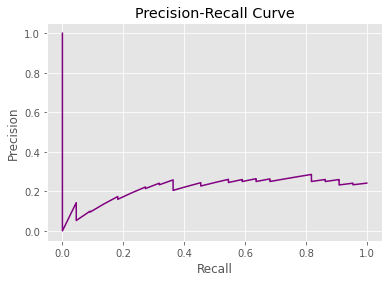

2022-07-14 17:41:40.951135: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


Run 5 
Test Set AUC Score for the ROC Curve: 0.5988142292490118


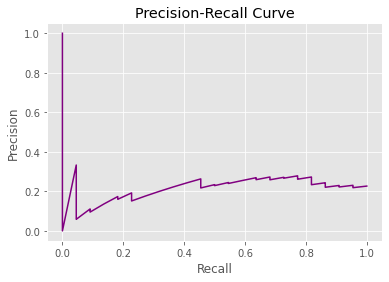

In [11]:
class SiameseTestGenerator(Sequence):
    def __init__(self, images, batch_size=BATCH_SIZE):
        self.images_t0 = images[0]
        self.images_tt = images[1]
        self.batch_size = batch_size

    def __len__(self):
        return len(self.images_t0)//self.batch_size
    
    def __getitem__(self, index):
        
        if(index == self.__len__()-1):
            X_t0 = self.images_t0[index*self.batch_size:len(self.images_t0)]
            X_tt = self.images_tt[index*self.batch_size:len(self.images_t0)]
        else:
            X_t0 = self.images_t0[index*self.batch_size:(index+1)*self.batch_size]          
            X_tt = self.images_tt[index*self.batch_size:(index+1)*self.batch_size]          
    
        
        return {'images_t0':X_t0, 'images_tt':X_tt}



for i in range(0, 5):
    model_path = f'../models/{CITY}/snn/run_{i}'
    best_model = load_model(model_path, custom_objects={'auc':metrics.AUC(num_thresholds=200, curve='ROC', name='auc')})
    test_generator = SiameseTestGenerator((test_images_t0, test_images_tt))
    yhat_proba, y = np.squeeze(best_model.predict(test_generator)[0:test_labels[:].shape[0]]), np.squeeze(test_labels[:])
    roc_auc_test = roc_auc_score(y, yhat_proba)
    #calculate precision and recall
    precision, recall, thresholds = precision_recall_curve(y, yhat_proba)


    #create precision recall curve
    fig, ax = plt.subplots()
    ax.plot(recall, precision, color='purple')

    #add axis labels to plot
    ax.set_title('Precision-Recall Curve')
    ax.set_ylabel('Precision')
    ax.set_xlabel('Recall')

    print(f'Run {i+1} \nTest Set AUC Score for the ROC Curve: {roc_auc_test}' )
    #display plot
    plt.show()

```
filters=32, dropout=0.13163265306122449, epochs=77, units=32, learning_rate=0.01
filters=32, dropout=0.18571428571428572, epochs=88, units=48, learning_rate=0.003

Upto 88
filters=32, 
dropout=0.1939, 
epochs=77, 
units=32, 
learning_rate=0.012


```